<a href="https://colab.research.google.com/github/KRBAI/Assignment-2/blob/main/Question10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

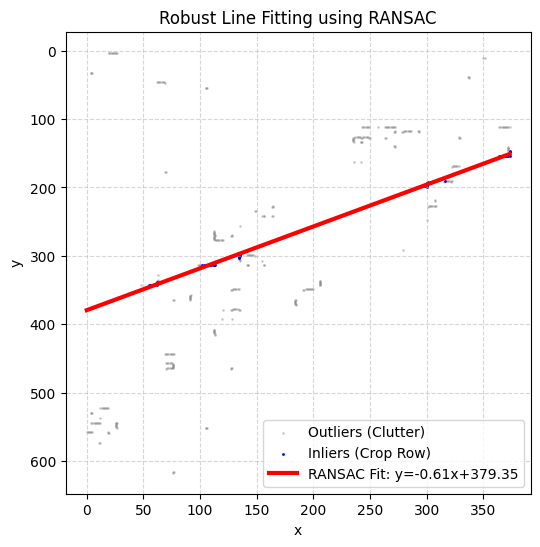

RANSAC Estimated Slope (m): -0.6119116918784819


In [17]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor

# Load the cropped segment of the image
img = cv.imread('/content/drive/MyDrive/Assignment2/Images/Screen Shot 2026-03-18 at 16.18.34.png', cv.IMREAD_GRAYSCALE)

X = x.reshape(-1, 1)

ransac = RANSACRegressor(residual_threshold=5.0, random_state=42)
ransac.fit(X, y)

m_robust = ransac.estimator_.coef_[0]
b_robust = ransac.estimator_.intercept_

x_fit = np.array([np.min(x), np.max(x)])
y_fit = m_robust * x_fit + b_robust

inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)

plt.figure(figsize=(6, 6))

plt.scatter(x[outlier_mask], y[outlier_mask], s=1, c='gray', alpha=0.3, label='Outliers (Clutter)')
plt.scatter(x[inlier_mask], y[inlier_mask], s=1, c='blue', label='Inliers (Crop Row)')

plt.plot(x_fit, y_fit, color='red', linewidth=3, label=f'RANSAC Fit: y={m_robust:.2f}x+{b_robust:.2f}')

plt.gca().invert_yaxis()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Robust Line Fitting using RANSAC')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"RANSAC Estimated Slope (m): {m_robust}")